In [61]:
pip install plotly


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
#Esenciales para data
import pandas as pd
import numpy as np
#para temas graficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [63]:
#configuracion grafica
plt.style.use('seaborn-v0_8-whitegrid') #Estilo de las graficas matplotlib
sns.set_style("whitegrid") #Estilo de las graficas seaborn
plt.rcParams['figure.figsize' ] = (12,4) #Tamaño del titulo de los ejes

In [64]:
df = pd.read_csv(r'C:\Users\Andrei.Baidurov\Titanic\data\titanic_limpio.csv')

In [65]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Tiene_cabina
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Sin Datos,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1


In [66]:
# crear una variable especifica que contenga la informacion que queremos en un nuestro grafico
supervientes_por_clase = df.groupby('Pclass')['Survived'].mean() *100

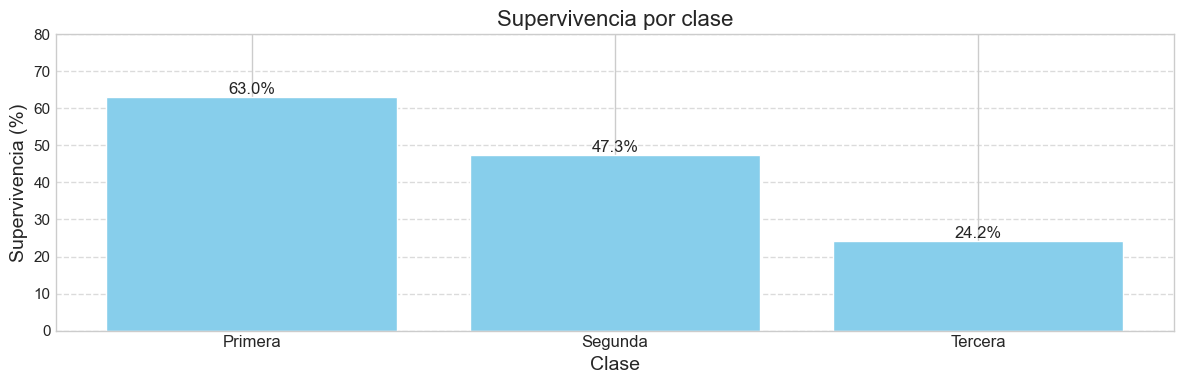

In [67]:
plt.figure(figsize=(12, 4))  # Corrected plt.Figure to plt.figure
# crea el grafico de barras
bars = plt.bar(supervientes_por_clase.index, supervientes_por_clase.values, color='skyblue')  # Fixed spacing and attribute access
# añadir etiquetas a las barras
for bar in bars:
	height = bar.get_height()  # Fixed indentation
	plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', ha='center', va='bottom', fontsize=12)  # Fixed spacing in f-string
# añadir etiquetas y titulos
plt.title('Supervivencia por clase', fontsize=16)
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Supervivencia (%)', fontsize=14)
plt.xticks(supervientes_por_clase.index, ['Primera', 'Segunda', 'Tercera'], fontsize=12)  # Fixed brackets and spacing
plt.ylim(0, 80)  # Removed extra period
# añadimos una cuadricula
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Fixed spacing in linestyle
plt.tight_layout()  # ajustar el grafico
plt.show()  # mostrar el grafico

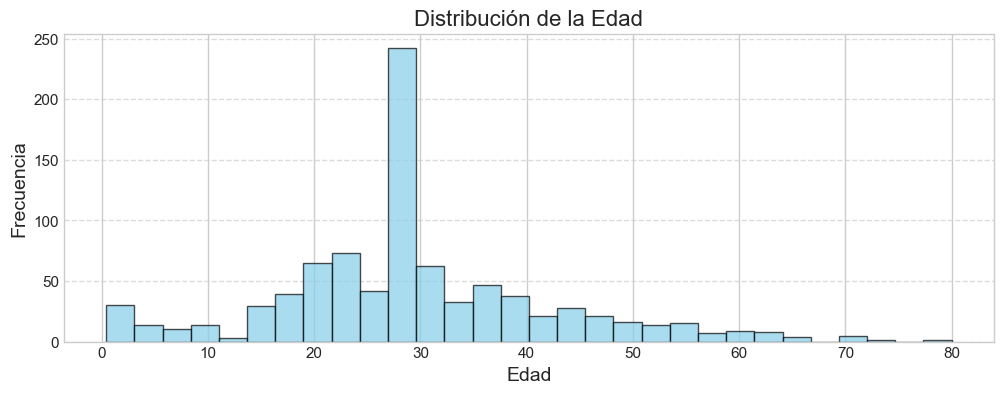

In [68]:
### hist plost (histograma)
plt.figure(figsize=(12,4))
edad = df[ 'Age' ].dropna() # Eliminar valores NaN de la columna 'Age'
n, bins, patches = plt.hist(edad, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de la Edad', fontsize=16)
plt.xlabel('Edad', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show() #mostrar el grafico

### Diagrama de dispercion

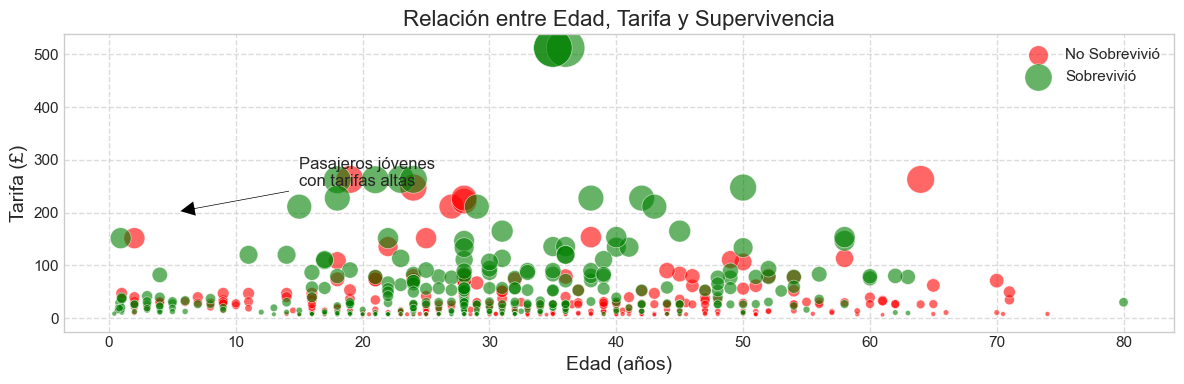

In [69]:
plt.figure(figsize=(12,4))
for survived, color, label in zip([0, 1], ['red', 'green'], ['No Sobrevivió', 'Sobrevivió']):
    # Filtrar datos
    subset = df[df['Survived'] == survived]
    
    # Crear el gráfico de dispersión
    plt.scatter(subset['Age'], subset['Fare'], 
                c=color, alpha=0.6, edgecolors='w', linewidth=0.5,
                label=label, s=subset['Fare']*1.5)  # Tamaño proporcional a la tarifa

# Añadir títulos y etiquetas
plt.title('Relación entre Edad, Tarifa y Supervivencia', fontsize=16)
plt.xlabel('Edad (años)', fontsize=14)
plt.ylabel('Tarifa (£)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Anotaciones para contexto
plt.annotate('Pasajeros jóvenes \ncon tarifas altas', 
             xy=(5, 200), xytext=(15, 250),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))

plt.tight_layout()
plt.show()

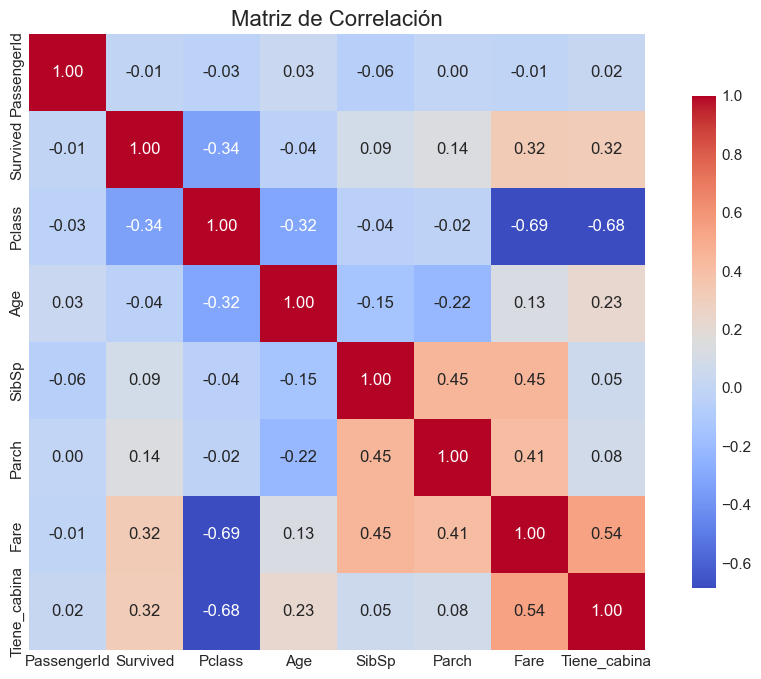

In [70]:
corr_matrix = df.select_dtypes(include=[np.number]).corr(method='spearman')
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación', fontsize=16)
plt.show()


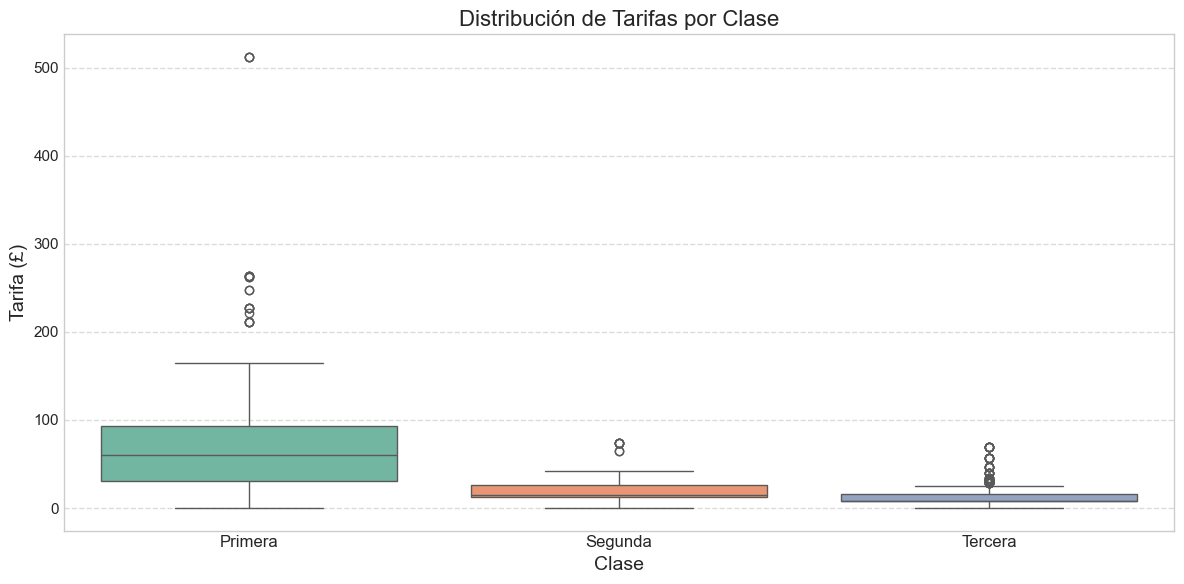

In [71]:
# Crea un boxplot para visualizar la distribución de las tarifas por clase
plt.figure(figsize=(12, 6))
sns.boxplot(x='Pclass', y='Fare', hue='Pclass', data=df, palette='Set2', dodge=False, legend=False)
plt.title('Distribución de Tarifas por Clase', fontsize=16)
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Tarifa (£)', fontsize=14)
plt.xticks([0, 1, 2], ['Primera', 'Segunda', 'Tercera'], fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()  # Mostrar el gráfico

C:\Users\Andrei.Baidurov\AppData\Local\Temp\ipykernel_15956\4171498296.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




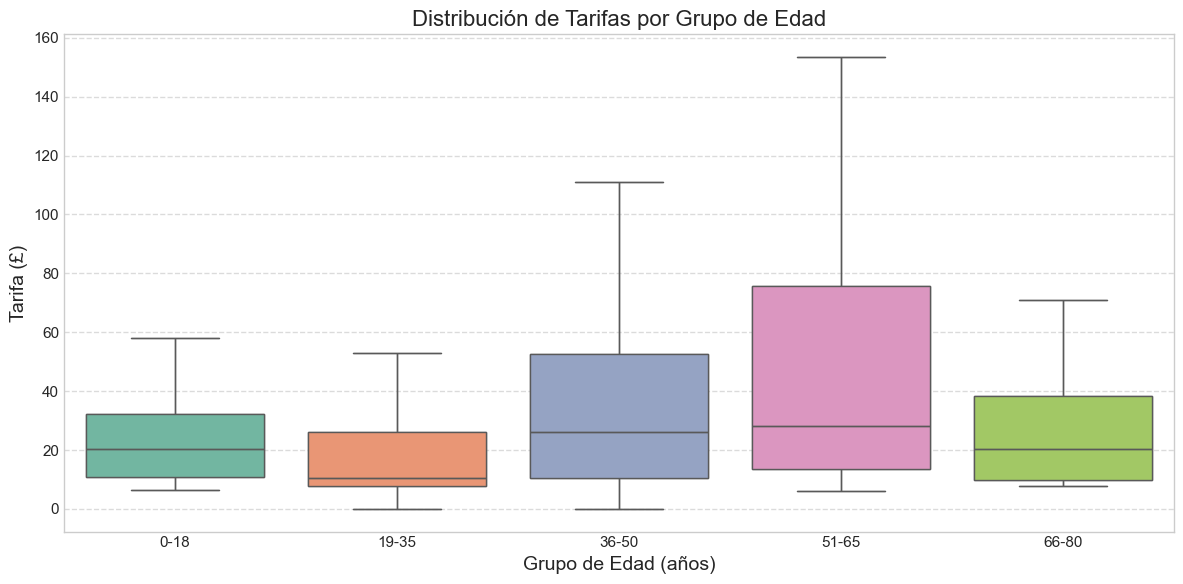

In [72]:
import seaborn as sns

# Verificar si la columna 'Age' existe en el dataframe
if 'Age' in df.columns:
	# Crear una nueva columna para agrupar edades en rangos
	df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 18, 35, 50, 65, 80], labels=['0-18', '19-35', '36-50', '51-65', '66-80'], include_lowest=True)

	# Crear el gráfico combinado
	plt.figure(figsize=(12, 6))
	sns.boxplot(x='AgeGroup', y='Fare', data=df, palette='Set2', showfliers=False)  # Boxplot sin outliers

	# Añadir títulos y etiquetas
	plt.title('Distribución de Tarifas por Grupo de Edad', fontsize=16)
	plt.xlabel('Grupo de Edad (años)', fontsize=14)
	plt.ylabel('Tarifa (£)', fontsize=14)

	# Añadir una cuadrícula
	plt.grid(axis='y', linestyle='--', alpha=0.7)

	plt.tight_layout()
	sns.boxplot(x='AgeGroup', y='Fare', hue='AgeGroup', data=df, palette='Set2', showfliers=False, dodge=False, legend=False)  # Boxplot sin outliers
	plt.show()
else:
	print("La columna 'Age' no existe en el dataframe.")

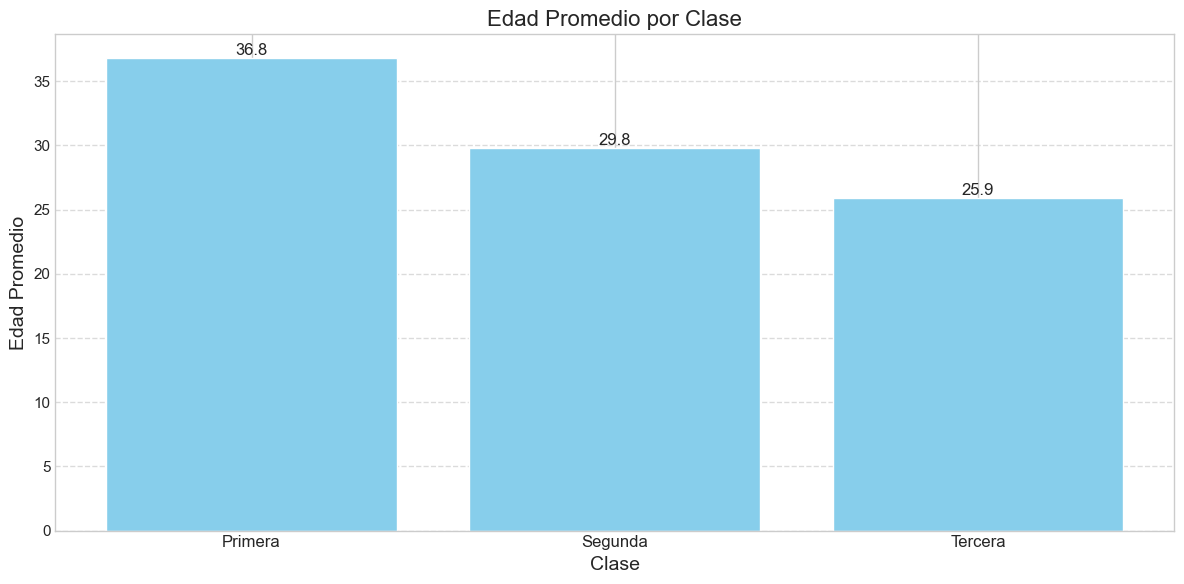

In [73]:
# Calcular la edad promedio por clase
edad_promedio_por_clase = df.groupby('Pclass')['Age'].mean()

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
bars = plt.bar(edad_promedio_por_clase.index, edad_promedio_por_clase.values, color='skyblue')

# Añadir etiquetas a las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}', ha='center', va='bottom', fontsize=12)

# Añadir títulos y etiquetas
plt.title('Edad Promedio por Clase', fontsize=16)
plt.xlabel('Clase', fontsize=14)
plt.ylabel('Edad Promedio', fontsize=14)
plt.xticks(edad_promedio_por_clase.index, ['Primera', 'Segunda', 'Tercera'], fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [74]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [75]:
pip install nbformat


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
# Corrected code
fig = px.scatter(
	df, 
	x='Age', 
	y='Fare', 
	color='Survived', 
	size='Fare',
	hover_name='Name', 
	size_max=30,
	color_discrete_map={0: 'red', 1: 'green'},
	labels={'Survived': 'Sobrevivió'},
	title='Relación entre Edad, Tarifa y Supervivencia'
)

# Personalizar el gráfico
fig.update_layout(
	title_font_size=20,
	xaxis_title="Edad (años)",
	yaxis_title='Tarifa (£)',
	legend_title='Sobrevivió',
	xaxis_title_font_size=16,
	yaxis_title_font_size=16,
	legend_title_font_size=14
)

# Actualizar leyenda
fig.update_layout(legend=dict(
	itemsizing='constant',
	title_font=dict(size=14),
	font=dict(size=12),
	yanchor="top",
	y=0.99,
	xanchor="right",
	x=0.99
))

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed